# RAG (Retrieval-Augmented Generation)

RAG is a technique that combines **information retrieval** with **language generation**.  
The model first retrieves relevant documents from a knowledge base and then uses them as context to generate accurate and grounded responses.

---

## Benefits of Using RAG
<!--  -->
1. **Up-to-date Information**  
   Retrieves the latest data from external sources instead of relying only on training data.

2. **Better Privacy**  
   Sensitive data can remain in private databases instead of being used for model training.

3. **No Document Size Limit**  
   Large documents can be stored externally and retrieved in chunks when needed.

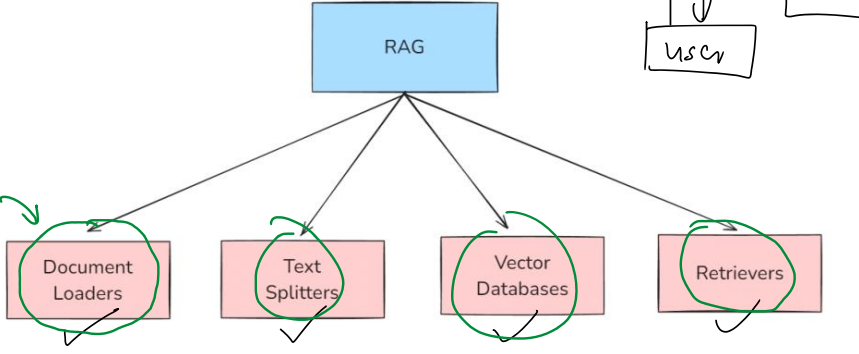
## Document Loaders

Document Loaders are components in LangChain used to load data from various sources into a standardized format (usually as `Document` objects).

These `Document` objects can then be used for:

- Text chunking (Text Splitters)  
- Embedding generation  
- Storing in Vector Databases  
- Retrieval in RAG pipelines
  
A `Document` in LangChain contains:

- `page_content` → The main text data  
- `metadata` → Additional information about the document 
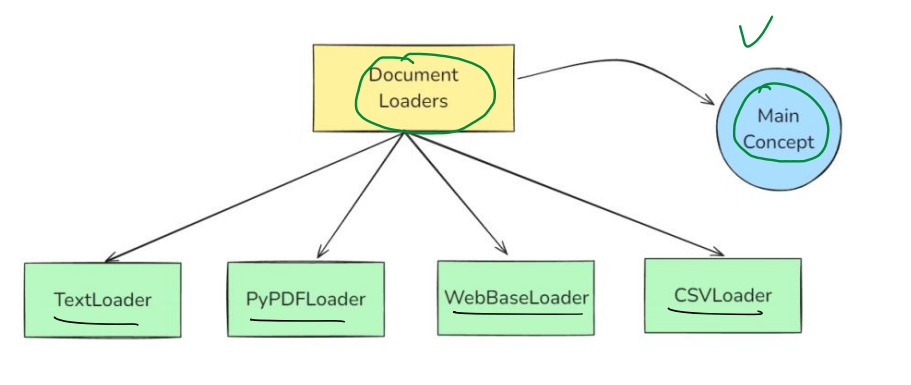

### TextLoader

`TextLoader` is a simple and commonly used document loader in LangChain that reads plain text (`.txt`) files and converts them into LangChain `Document` objects.

**Use Case:** Load chat logs, transcripts, scraped text, or any plain text into a pipeline.  

**Limitation:** Supports only `.txt` files. 

In [3]:
from langchain_community.document_loaders import TextLoader

/mnt/d/Learning/Java/genAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
loader = TextLoader('cricket.txt', encoding='utf-8')
docs = loader.load()

In [13]:
print(type(docs),len(docs),type(docs[0]))
print("Metadata: ", docs[0].metadata)
print("Content: ", docs[0].page_content)

<class 'list'> 1 <class 'langchain_core.documents.base.Document'>
Metadata:  {'source': 'cricket.txt'}
Content:  On a sunlit field where dreams take flight,
The bat meets ball in pure delight.
Cheers rise high from every side,
As hope and glory gently collide.

The bowler runs with steady pace,
Fire and focus on his face.
A spinning ball, a flashing drive,
The crowd erupts — the game’s alive!

From dusty grounds to stadium bright,
Cricket unites in shared excitement.
A game of patience, skill, and art,
Played with passion, mind, and heart.


In [8]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
load_dotenv()

True

In [9]:
model = ChatOpenAI()


# 1st Prompt - Detailed Report
prompt = PromptTemplate(
    template='Write a summary on \n{poem}',
    input_variables=['poem']
)

parser = StrOutputParser()

In [14]:
chain = prompt | model | parser
result = chain.invoke({
    'poem':docs[0].page_content
})

In [15]:
print(result)

The poem captures the essence of a cricket match, where players and fans come together in excitement and joy. The sunlit field serves as the stage for dreams to take flight, as the bat meets ball with pure delight. With cheers rising high on all sides, hope and glory collide in a display of passion and skill. From the bowler's steady pace to the spinning ball and flashing drives, the game comes alive with every moment. Cricket is portrayed as a game that unites people in shared excitement, requiring patience, skill, and artistry to play. It is a sport played with passion, mind, and heart, creating a sense of unity and camaraderie among all involved.


## PyPDFLoader

`PyPDFLoader` is a document loader in LangChain used to load content from PDF files and convert each page into a `Document` object.

---
### Limitation

- Uses the PyPDF library internally  
- Not suitable for scanned PDFs (image-based PDFs)  
- Struggles with complex layouts or tables  

In [17]:
from langchain_community.document_loaders import PyPDFLoader

# Load PDF file
loader = PyPDFLoader("dl-curriculum.pdf")

# Each page becomes a separate Document
documents = loader.load()

# Access first page
print(documents[0].page_content)
print(documents[0].metadata)

CampusXDeepLearningCurriculum
A.ArtificialNeuralNetworkandhowtoimprovethem
1.BiologicalInspiration
● Understandingtheneuronstructure● Synapsesandsignal transmission● Howbiological conceptstranslatetoartificial neurons
2.HistoryofNeuralNetworks
● Earlymodels(Perceptron)● BackpropagationandMLPs● The"AI Winter" andresurgenceof neural networks● Emergenceof deeplearning
3.PerceptronandMultilayerPerceptrons(MLP)
● Single-layer perceptronlimitations● XORproblemandtheneedfor hiddenlayers● MLParchitecture
4. LayersandTheirFunctions
● InputLayer○ Acceptinginput data● HiddenLayers○ Featureextraction● OutputLayer○ Producingfinal predictions
5.ActivationFunctions
{'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Deep Learning Curriculum', 'source': 'dl-curriculum.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}


## DirectoryLoader

`DirectoryLoader` is a document loader in LangChain that allows you to load multiple documents from a directory (folder). It scans the folder, loads all supported files, and converts them into `Document` objects for further processing in a pipeline.

## load() vs lazy_load()

### load() → Eager Loading
- Loads **all documents at once** into memory  
- Returns a **list of Document objects**  
- Best when:
  - Number of documents is small  
  - You want everything loaded upfront  

---

### lazy_load() → Lazy Loading
- Loads documents **on demand (one by one)**  
- Returns a **generator of Document objects**  
- Documents are fetched only when needed  
- Best when:
  - You have large documents or many files  
  - You want streaming processing (chunking, embedding)  
  - You want to save memory  

In [24]:
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader

loader = DirectoryLoader(
    path = "exampleDirectory",
    glob = '*.pdf',
    loader_cls=PyPDFLoader
)

In [21]:
documents = loader.load()

print(f"Total Documents Loaded: {len(documents)}")

# Print first document
print(documents[0].page_content)
print(documents[0].metadata)

Total Documents Loaded: 326
[ 1 ]
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': 'exampleDirectory/Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 0, 'page_label': 'Cover'}


In [ ]:
# Lazy Loading
for doc in loader.lazy_load():
    print(doc.metadata)

## WebBaseLoader

`WebBaseLoader` is a document loader in LangChain used to load and extract text content from web pages (URLs).

It uses **BeautifulSoup** internally to parse HTML and extract visible text.

---

### When to Use

- Blogs  
- News articles  
- Public websites  
- Text-based and mostly static web pages  

---

### Limitations

- Does not handle JavaScript-heavy pages well  
  (Use `SeleniumURLLoader` for dynamic websites)  
- Loads only static HTML content  
  (Does not capture content rendered after page load) 

In [26]:
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [35]:
url = 'https://www.geeksforgeeks.org/artificial-intelligence/langchain-document-loaders/'
loader = WebBaseLoader(url)

In [36]:
docs = loader.load()

In [ ]:
print(len(docs))
print(docs[0])

In [38]:
# 1st Prompt - Detailed Report
prompt = PromptTemplate(
    template='Answer the following question \n{question} \n on {text} ',
    input_variables=['question','text']
)

In [39]:
chain = prompt | model | parser

In [40]:
questions = [
    "What is the main purpose of Document Loaders in LangChain?",
    "What are the two main fields stored inside a LangChain Document object?",
    "How does CSVLoader convert CSV data into Document objects?",
    "Which loader is used to fetch data from Wikipedia in LangChain?",
    "What is the role of DirectoryLoader in loading documents?"
]
text = docs[0]

In [42]:
result = chain.invoke({
    'question':questions,
    'text':text
})

In [43]:
print(result)

The main purpose of Document Loaders in LangChain is to convert data from various formats such as CSV, PDF, HTML, and JSON into standardized Document objects. These objects contain the raw content, metadata, and optional identifiers, allowing LLMs (Language Model Machines) to process and analyze the data efficiently. 

The two main fields stored inside a LangChain Document object are:
1. page_content: Stores the textual content of the document.
2. metadata: Provides additional information about the document like source or category.

CSVLoader converts CSV data into Document objects by loading each row of a CSV file as a separate Document object. It uses the file path, metadata columns, and CSV parsing arguments to create Document objects.

The loader used to fetch data from Wikipedia in LangChain is the WikipediaLoader, which fetches articles based on search queries and includes metadata like categories, references, and image URLs.

The role of DirectoryLoader in loading documents is t

## CSVLoader

`CSVLoader` is a document loader in LangChain used to load CSV files into `Document` objects — creating one `Document` per row by default.


In [45]:
from langchain_community.document_loaders import CSVLoader

# Load CSV file
loader = CSVLoader(file_path="Social_Network_Ads.csv")

# Each row becomes a separate Document
documents = loader.load()

print(f"Total rows loaded: {len(documents)}")

# Print first row
print(documents[0].page_content)
print(documents[0].metadata)

Total rows loaded: 400
User ID: 15624510
Gender: Male
Age: 19
EstimatedSalary: 19000
Purchased: 0
{'source': 'Social_Network_Ads.csv', 'row': 0}
